In [2]:

# from google.colab import drive
# drive.mount('/content/drive')

!pip install -q pyclipper shapely

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from shapely.geometry import Polygon
import pyclipper
import json
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 14.1 MB/s eta 0:00:00


In [3]:

# ============== DETERMINISTIC SEED ==============
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✓ Random seed set to {SEED} (fully deterministic)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

✓ Random seed set to 42 (fully deterministic)
Device: cuda


In [4]:

# Path to your single image data
DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/train-ocr-model')
SINGLE_IMAGE_DIR = DATA_DIR / 'single_image_data'

image_path = SINGLE_IMAGE_DIR / 'img_single.png'
json_path = SINGLE_IMAGE_DIR / 'img_single.json'

# Read image
original_image = cv2.imread(str(image_path))
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
H, W, C = original_image.shape

print(f"{'='*60}")
print(f"IMAGE LOADED: img_single.png")
print(f"{'='*60}")
print(f"  Shape: {original_image.shape}  →  (Height={H}, Width={W}, Channels={C})")
print(f"  Dtype: {original_image.dtype}")
print(f"  Pixel range: [{original_image.min()}, {original_image.max()}]")

# Parse Label Studio JSON
with open(json_path, 'r', encoding='utf-8') as f:
    label_studio_data = json.load(f)

# Extract polygon annotations
# Label Studio stores points as percentages (0-100) of image width/height
annotations = label_studio_data[0]['annotations'][0]['result']

polygons = []
texts = []

# Label Studio has paired results: 'polygon' type and 'textarea' type with same id
poly_dict = {}   # id -> polygon points
text_dict = {}   # id -> text

for ann in annotations:
    ann_id = ann['id']
    ann_type = ann['type']

    if ann_type == 'polygon':
        # Convert percentage points to pixel coordinates
        points_pct = ann['value']['points']  # [[x%, y%], [x%, y%], ...]
        points_px = []
        for px, py in points_pct:
            x = int(px * W / 100.0)
            y = int(py * H / 100.0)
            points_px.append([x, y])
        poly_dict[ann_id] = np.array(points_px, dtype=np.int32)

    elif ann_type == 'textarea':
        text_val = ann['value'].get('text', [''])
        text_dict[ann_id] = text_val[0] if text_val else ''

# Merge polygons with their text
for ann_id, poly in poly_dict.items():
    polygons.append(poly)
    texts.append(text_dict.get(ann_id, ''))

# No ignore flags for this custom data (all valid)
ignore_flags = [False] * len(polygons)

print(f"\n  Total text regions: {len(polygons)}")
print(f"\n  First 10 annotations:")
for i in range(min(10, len(polygons))):
    poly = polygons[i]
    text = texts[i]
    print(f"    [{i:2d}] Text: '{text}' | Box: {poly.tolist()}")

if len(polygons) > 10:
    print(f"    ... and {len(polygons) - 10} more")

IMAGE LOADED: img_single.png
  Shape: (748, 592, 3)  →  (Height=748, Width=592, Channels=3)
  Dtype: uint8
  Pixel range: [0, 255]

  Total text regions: 49

  First 10 annotations:
    [ 0] Text: 'how are you' | Box: [[11, 101], [282, 101], [280, 132], [11, 130]]
    [ 1] Text: 'd' | Box: [[12, 41], [144, 42], [144, 67], [13, 67]]
    [ 2] Text: 'd' | Box: [[190, 40], [354, 40], [354, 68], [191, 68]]
    [ 3] Text: 'd' | Box: [[402, 38], [535, 38], [535, 69], [403, 68]]
    [ 4] Text: 'd' | Box: [[501, 76], [502, 97], [400, 98], [400, 75]]
    [ 5] Text: 'd' | Box: [[103, 77], [103, 98], [11, 97], [12, 76]]
    [ 6] Text: 'd' | Box: [[192, 76], [192, 95], [234, 96], [233, 77]]
    [ 7] Text: 'e' | Box: [[359, 107], [530, 105], [531, 129], [357, 129]]
    [ 8] Text: 'd' | Box: [[13, 137], [14, 160], [387, 162], [391, 138]]
    [ 9] Text: 'd' | Box: [[414, 139], [459, 140], [459, 162], [417, 161]]
    ... and 39 more


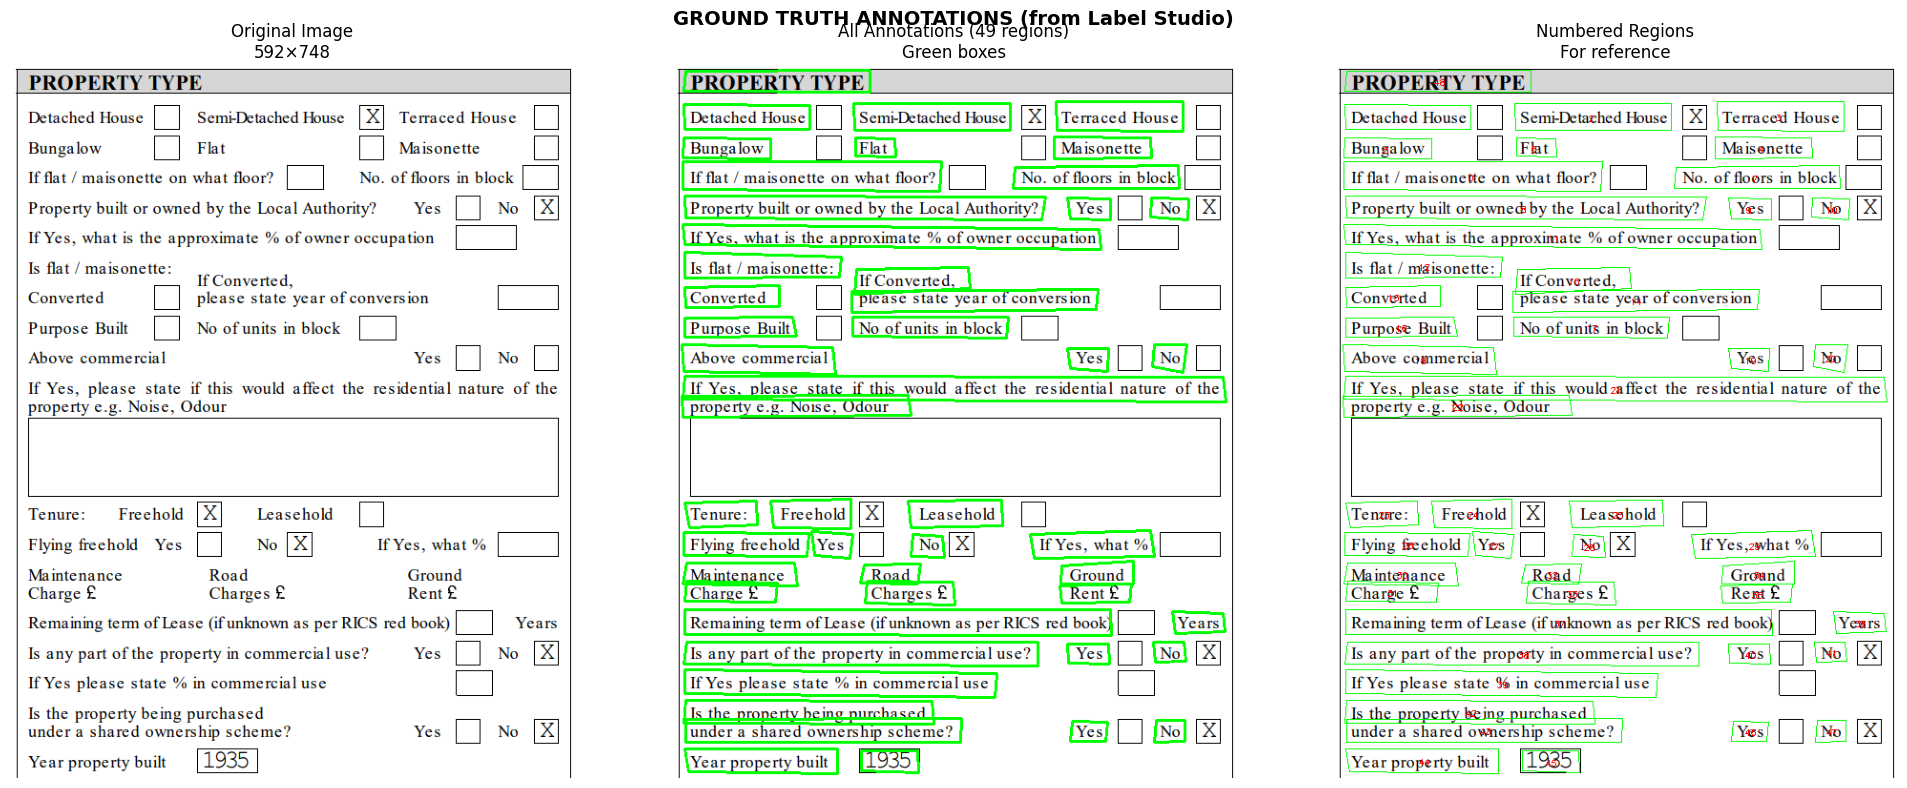

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1. Original image
axes[0].imshow(original_image)
axes[0].set_title(f'Original Image\n{W}×{H}', fontsize=12)
axes[0].axis('off')

# 2. Image with ALL boxes
img_all = original_image.copy()
for poly, text in zip(polygons, texts):
    cv2.polylines(img_all, [poly], True, (0, 255, 0), 2)

axes[1].imshow(img_all)
axes[1].set_title(f'All Annotations ({len(polygons)} regions)\nGreen boxes', fontsize=12)
axes[1].axis('off')

# 3. Numbered boxes for reference
img_num = original_image.copy()
for i, (poly, text) in enumerate(zip(polygons, texts)):
    cv2.polylines(img_num, [poly], True, (0, 255, 0), 1)
    cx = int(poly[:, 0].mean())
    cy = int(poly[:, 1].mean())
    cv2.putText(img_num, str(i), (cx-5, cy+5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1)

axes[2].imshow(img_num)
axes[2].set_title(f'Numbered Regions\nFor reference', fontsize=12)
axes[2].axis('off')

plt.suptitle('GROUND TRUTH ANNOTATIONS (from Label Studio)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

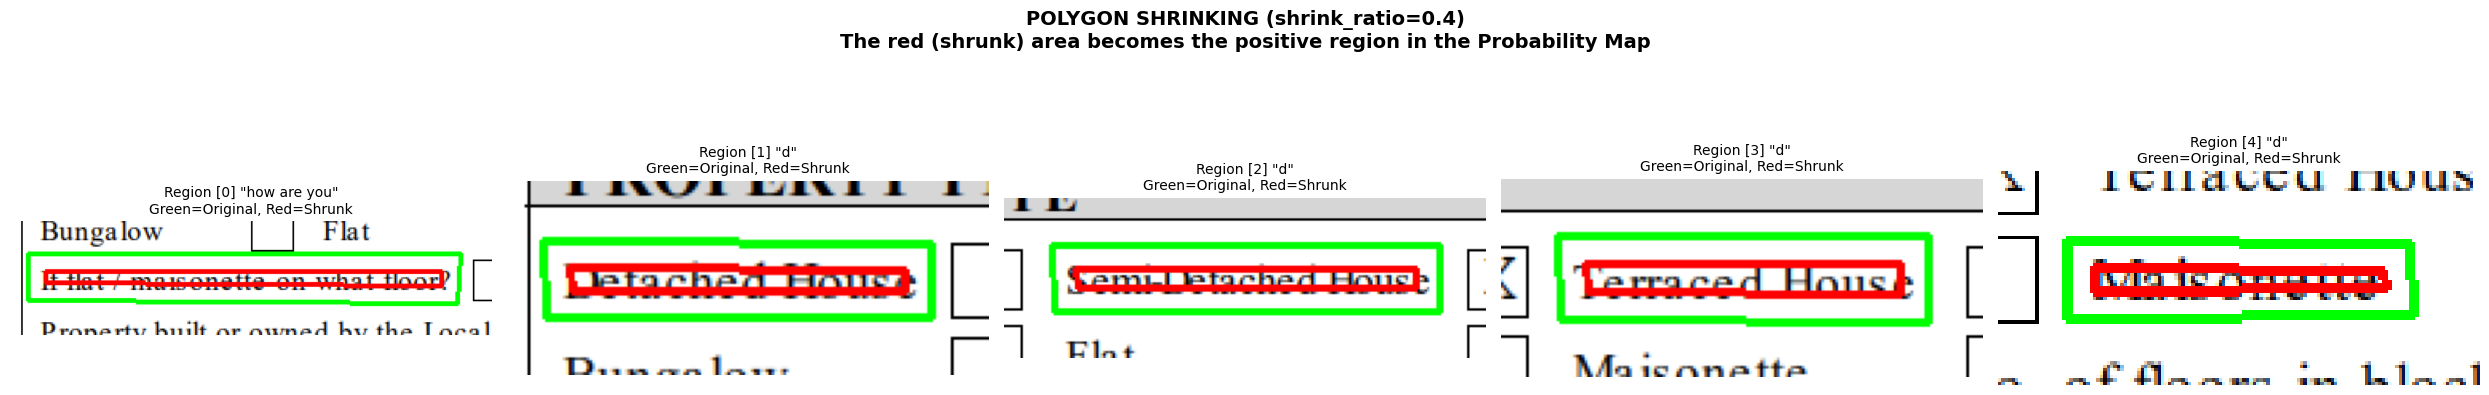


POLYGON SHRINKING MATH

  Region [0] 'how are you':
    Area = 8101.0 px²
    Perimeter = 600.1 px
    Shrink distance = Area × (1 - 0.4²) / Perimeter = 11.3 px

  Region [1] 'd':
    Area = 3353.0 px²
    Perimeter = 314.0 px
    Shrink distance = Area × (1 - 0.4²) / Perimeter = 9.0 px

  Region [2] 'd':
    Area = 4578.0 px²
    Perimeter = 383.0 px
    Shrink distance = Area × (1 - 0.4²) / Perimeter = 10.0 px

  Region [3] 'd':
    Area = 4041.0 px²
    Perimeter = 326.0 px
    Shrink distance = Area × (1 - 0.4²) / Perimeter = 10.4 px

  Region [4] 'd':
    Area = 2233.0 px²
    Perimeter = 247.0 px
    Shrink distance = Area × (1 - 0.4²) / Perimeter = 7.6 px


In [6]:

def shrink_polygon(polygon, shrink_ratio=0.4):
    """Shrink polygon inward. Creates the 'inner boundary' for probability map."""
    poly = Polygon(polygon)
    area = poly.area
    perimeter = poly.length

    if area < 1 or perimeter < 1:
        return None

    shrink_distance = area * (1 - shrink_ratio ** 2) / perimeter

    pco = pyclipper.PyclipperOffset()
    pco.AddPath(polygon.astype(np.int64).tolist(),
                pyclipper.JT_ROUND, pyclipper.ET_CLOSEDPOLYGON)

    shrunk = pco.Execute(-shrink_distance)

    if len(shrunk) == 0:
        return None
    return np.array(shrunk[0])


# Visualize shrinking for first 5 polygons
num_show = min(5, len(polygons))
fig, axes = plt.subplots(1, num_show, figsize=(5*num_show, 5))
if num_show == 1:
    axes = [axes]

for idx in range(num_show):
    poly = polygons[idx]
    text = texts[idx]

    x_min, y_min = poly.min(axis=0) - 20
    x_max, y_max = poly.max(axis=0) + 20
    x_min, y_min = max(0, x_min), max(0, y_min)
    x_max, y_max = min(W, x_max), min(H, y_max)

    region = original_image[y_min:y_max, x_min:x_max].copy()

    shifted_poly = poly - np.array([x_min, y_min])
    cv2.polylines(region, [shifted_poly], True, (0, 255, 0), 2)

    shrunk = shrink_polygon(poly)
    if shrunk is not None:
        shifted_shrunk = shrunk - np.array([x_min, y_min])
        cv2.polylines(region, [shifted_shrunk.astype(np.int32)], True, (255, 0, 0), 2)

    axes[idx].imshow(region)
    axes[idx].set_title(f'Region [{idx}] "{text[:15]}"\nGreen=Original, Red=Shrunk', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('POLYGON SHRINKING (shrink_ratio=0.4)\n'
             'The red (shrunk) area becomes the positive region in the Probability Map',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show the math for first few
print(f"\n{'='*60}")
print(f"POLYGON SHRINKING MATH")
print(f"{'='*60}")
for i in range(min(5, len(polygons))):
    poly = polygons[i]
    p = Polygon(poly)
    area = p.area
    perimeter = p.length
    d = area * (1 - 0.4**2) / perimeter
    print(f"\n  Region [{i}] '{texts[i][:20]}':")
    print(f"    Area = {area:.1f} px²")
    print(f"    Perimeter = {perimeter:.1f} px")
    print(f"    Shrink distance = Area × (1 - 0.4²) / Perimeter = {d:.1f} px")

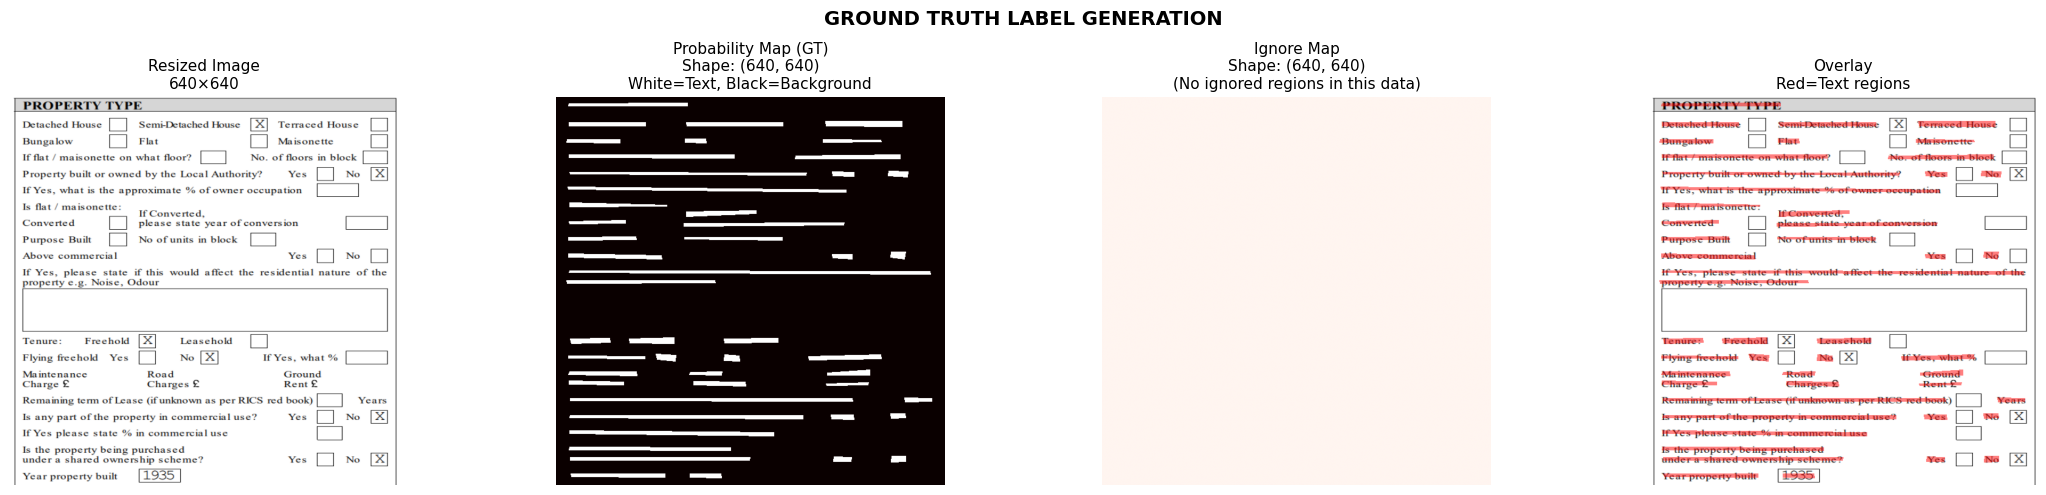


PROBABILITY MAP STATISTICS
  Map size: 640×640 = 409,600 pixels
  Text pixels:       44,953 (10.97%)
  Background pixels: 364,647 (89.03%)
  → Severe class imbalance! That's why we use Dice Loss + OHEM


In [7]:

IMG_SIZE = 640

# Resize image
image_resized = cv2.resize(original_image, (IMG_SIZE, IMG_SIZE))
scale_x = IMG_SIZE / W
scale_y = IMG_SIZE / H

# Scale polygons
scaled_polygons = []
for poly in polygons:
    sp = poly.copy().astype(np.float32)
    sp[:, 0] *= scale_x
    sp[:, 1] *= scale_y
    scaled_polygons.append(sp)

# Generate probability map
prob_map = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
ignore_map = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

for poly, ign in zip(scaled_polygons, ignore_flags):
    if ign:
        cv2.fillPoly(ignore_map, [poly.astype(np.int32)], 1.0)
        continue
    shrunk = shrink_polygon(poly, 0.4)
    if shrunk is not None:
        cv2.fillPoly(prob_map, [shrunk.astype(np.int32)], 1.0)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(image_resized)
axes[0].set_title(f'Resized Image\n{IMG_SIZE}×{IMG_SIZE}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
axes[1].set_title(f'Probability Map (GT)\nShape: {prob_map.shape}\n'
                  f'White=Text, Black=Background', fontsize=11)
axes[1].axis('off')

axes[2].imshow(ignore_map, cmap='Reds', vmin=0, vmax=1)
axes[2].set_title(f'Ignore Map\nShape: {ignore_map.shape}\n'
                  f'(No ignored regions in this data)', fontsize=11)
axes[2].axis('off')

# Overlay
overlay = image_resized.copy()
mask = prob_map > 0
overlay[mask] = overlay[mask] * 0.5 + np.array([255, 0, 0]) * 0.5

axes[3].imshow(overlay)
axes[3].set_title('Overlay\nRed=Text regions', fontsize=11)
axes[3].axis('off')

plt.suptitle('GROUND TRUTH LABEL GENERATION', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
total_pixels = IMG_SIZE * IMG_SIZE
text_pixels = int((prob_map > 0).sum())
bg_pixels = total_pixels - text_pixels
print(f"\n{'='*60}")
print(f"PROBABILITY MAP STATISTICS")
print(f"{'='*60}")
print(f"  Map size: {IMG_SIZE}×{IMG_SIZE} = {total_pixels:,} pixels")
print(f"  Text pixels:       {text_pixels:,} ({text_pixels/total_pixels*100:.2f}%)")
print(f"  Background pixels: {bg_pixels:,} ({bg_pixels/total_pixels*100:.2f}%)")
print(f"  → Severe class imbalance! That's why we use Dice Loss + OHEM")


In [8]:

class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResNet18Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.out_channels = [64, 128, 256, 512]

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        ds = None
        if stride != 1 or in_ch != out_ch:
            ds = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                               nn.BatchNorm2d(out_ch))
        layers = [BasicBlock(in_ch, out_ch, stride, ds)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        c1 = self.layer1(x)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        return [c1, c2, c3, c4]


class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([nn.Conv2d(c, out_channels, 1) for c in in_channels_list])
        self.smooth_convs = nn.ModuleList([nn.Conv2d(out_channels, out_channels // 4, 3, padding=1) for _ in in_channels_list])

    def forward(self, features):
        c1, c2, c3, c4 = features
        p4 = self.lateral_convs[3](c4)
        p3 = self.lateral_convs[2](c3) + F.interpolate(p4, size=c3.shape[2:], mode='bilinear', align_corners=True)
        p2 = self.lateral_convs[1](c2) + F.interpolate(p3, size=c2.shape[2:], mode='bilinear', align_corners=True)
        p1 = self.lateral_convs[0](c1) + F.interpolate(p2, size=c1.shape[2:], mode='bilinear', align_corners=True)

        p1 = self.smooth_convs[0](p1)
        p2 = F.interpolate(self.smooth_convs[1](p2), size=p1.shape[2:], mode='bilinear', align_corners=True)
        p3 = F.interpolate(self.smooth_convs[2](p3), size=p1.shape[2:], mode='bilinear', align_corners=True)
        p4 = F.interpolate(self.smooth_convs[3](p4), size=p1.shape[2:], mode='bilinear', align_corners=True)

        return torch.cat([p1, p2, p3, p4], dim=1)


class DBNetHead(nn.Module):
    def __init__(self, in_ch, k=50):
        super().__init__()
        self.k = k
        self.conv = nn.Sequential(nn.Conv2d(in_ch, in_ch // 4, 3, padding=1),
                                  nn.BatchNorm2d(in_ch // 4), nn.ReLU(inplace=True))
        self.prob_head = nn.Sequential(
            nn.ConvTranspose2d(in_ch // 4, in_ch // 4, 2, stride=2),
            nn.BatchNorm2d(in_ch // 4), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_ch // 4, 1, 2, stride=2), nn.Sigmoid())
        self.thresh_head = nn.Sequential(
            nn.ConvTranspose2d(in_ch // 4, in_ch // 4, 2, stride=2),
            nn.BatchNorm2d(in_ch // 4), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_ch // 4, 1, 2, stride=2), nn.Sigmoid())

    def forward(self, x):
        s = self.conv(x)
        prob = self.prob_head(s)
        thresh = self.thresh_head(s)
        binary = torch.sigmoid(self.k * (prob - thresh))
        return prob, thresh, binary


class DBNet(nn.Module):
    def __init__(self, k=50):
        super().__init__()
        self.backbone = ResNet18Backbone()
        self.fpn = FPN(self.backbone.out_channels, 256)
        self.head = DBNetHead(256, k)

    def forward(self, x):
        features = self.backbone(x)
        fused = self.fpn(features)
        return self.head(fused)

model = DBNet(k=50).to(device)
print(f"DBNet loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

DBNet loaded: 12,194,690 parameters


In [9]:

print(f"{'='*70}")
print(f"DIMENSION TRACE: Watching data flow through DBNet")
print(f"{'='*70}")

img_tensor = image_resized.astype(np.float32) / 255.0
img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device)

print(f"\n📥 INPUT")
print(f"   Image tensor: {img_tensor.shape}  →  (Batch=1, Channels=3, H={IMG_SIZE}, W={IMG_SIZE})")

model.eval()
with torch.no_grad():
    x = model.backbone.conv1(img_tensor)
    print(f"\n🔷 BACKBONE (ResNet-18)")
    print(f"   After conv1 (7×7, stride=2):  {x.shape}  →  H,W halved to {x.shape[2]}×{x.shape[3]}")
    x = model.backbone.maxpool(model.backbone.relu(model.backbone.bn1(x)))
    print(f"   After maxpool (3×3, stride=2): {x.shape}  →  H,W halved to {x.shape[2]}×{x.shape[3]}")

    c1 = model.backbone.layer1(x)
    print(f"   After layer1 (stride=1):       {c1.shape}  →  64 channels, {c1.shape[2]}×{c1.shape[3]} (1/4 of input)")
    c2 = model.backbone.layer2(c1)
    print(f"   After layer2 (stride=2):       {c2.shape}  →  128 channels, {c2.shape[2]}×{c2.shape[3]} (1/8 of input)")
    c3 = model.backbone.layer3(c2)
    print(f"   After layer3 (stride=2):       {c3.shape}  →  256 channels, {c3.shape[2]}×{c3.shape[3]} (1/16 of input)")
    c4 = model.backbone.layer4(c3)
    print(f"   After layer4 (stride=2):       {c4.shape}  →  512 channels, {c4.shape[2]}×{c4.shape[3]} (1/32 of input)")

    features = [c1, c2, c3, c4]
    fused = model.fpn(features)
    print(f"\n🔶 FPN (Feature Pyramid Network)")
    print(f"   Fused features: {fused.shape}  →  All scales merged to {fused.shape[1]} channels at {fused.shape[2]}×{fused.shape[3]}")

    shared = model.head.conv(fused)
    print(f"\n🔴 DETECTION HEAD")
    print(f"   After shared conv:   {shared.shape}  →  {shared.shape[1]} channels")

    prob, thresh, binary = model.head(fused)
    print(f"   Probability map:     {prob.shape}  →  1 channel, {prob.shape[2]}×{prob.shape[3]} (same as input!)")
    print(f"   Threshold map:       {thresh.shape}  →  1 channel, {thresh.shape[2]}×{thresh.shape[3]}")
    print(f"   Binary map:          {binary.shape}  →  1 channel, {binary.shape[2]}×{binary.shape[3]}")

print(f"\n📤 OUTPUT")
print(f"   All 3 maps are {IMG_SIZE}×{IMG_SIZE} with values in [0, 1]")

DIMENSION TRACE: Watching data flow through DBNet

📥 INPUT
   Image tensor: torch.Size([1, 3, 640, 640])  →  (Batch=1, Channels=3, H=640, W=640)

🔷 BACKBONE (ResNet-18)
   After conv1 (7×7, stride=2):  torch.Size([1, 64, 320, 320])  →  H,W halved to 320×320
   After maxpool (3×3, stride=2): torch.Size([1, 64, 160, 160])  →  H,W halved to 160×160
   After layer1 (stride=1):       torch.Size([1, 64, 160, 160])  →  64 channels, 160×160 (1/4 of input)
   After layer2 (stride=2):       torch.Size([1, 128, 80, 80])  →  128 channels, 80×80 (1/8 of input)
   After layer3 (stride=2):       torch.Size([1, 256, 40, 40])  →  256 channels, 40×40 (1/16 of input)
   After layer4 (stride=2):       torch.Size([1, 512, 20, 20])  →  512 channels, 20×20 (1/32 of input)

🔶 FPN (Feature Pyramid Network)
   Fused features: torch.Size([1, 256, 160, 160])  →  All scales merged to 256 channels at 160×160

🔴 DETECTION HEAD
   After shared conv:   torch.Size([1, 64, 160, 160])  →  64 channels
   Probability map: 

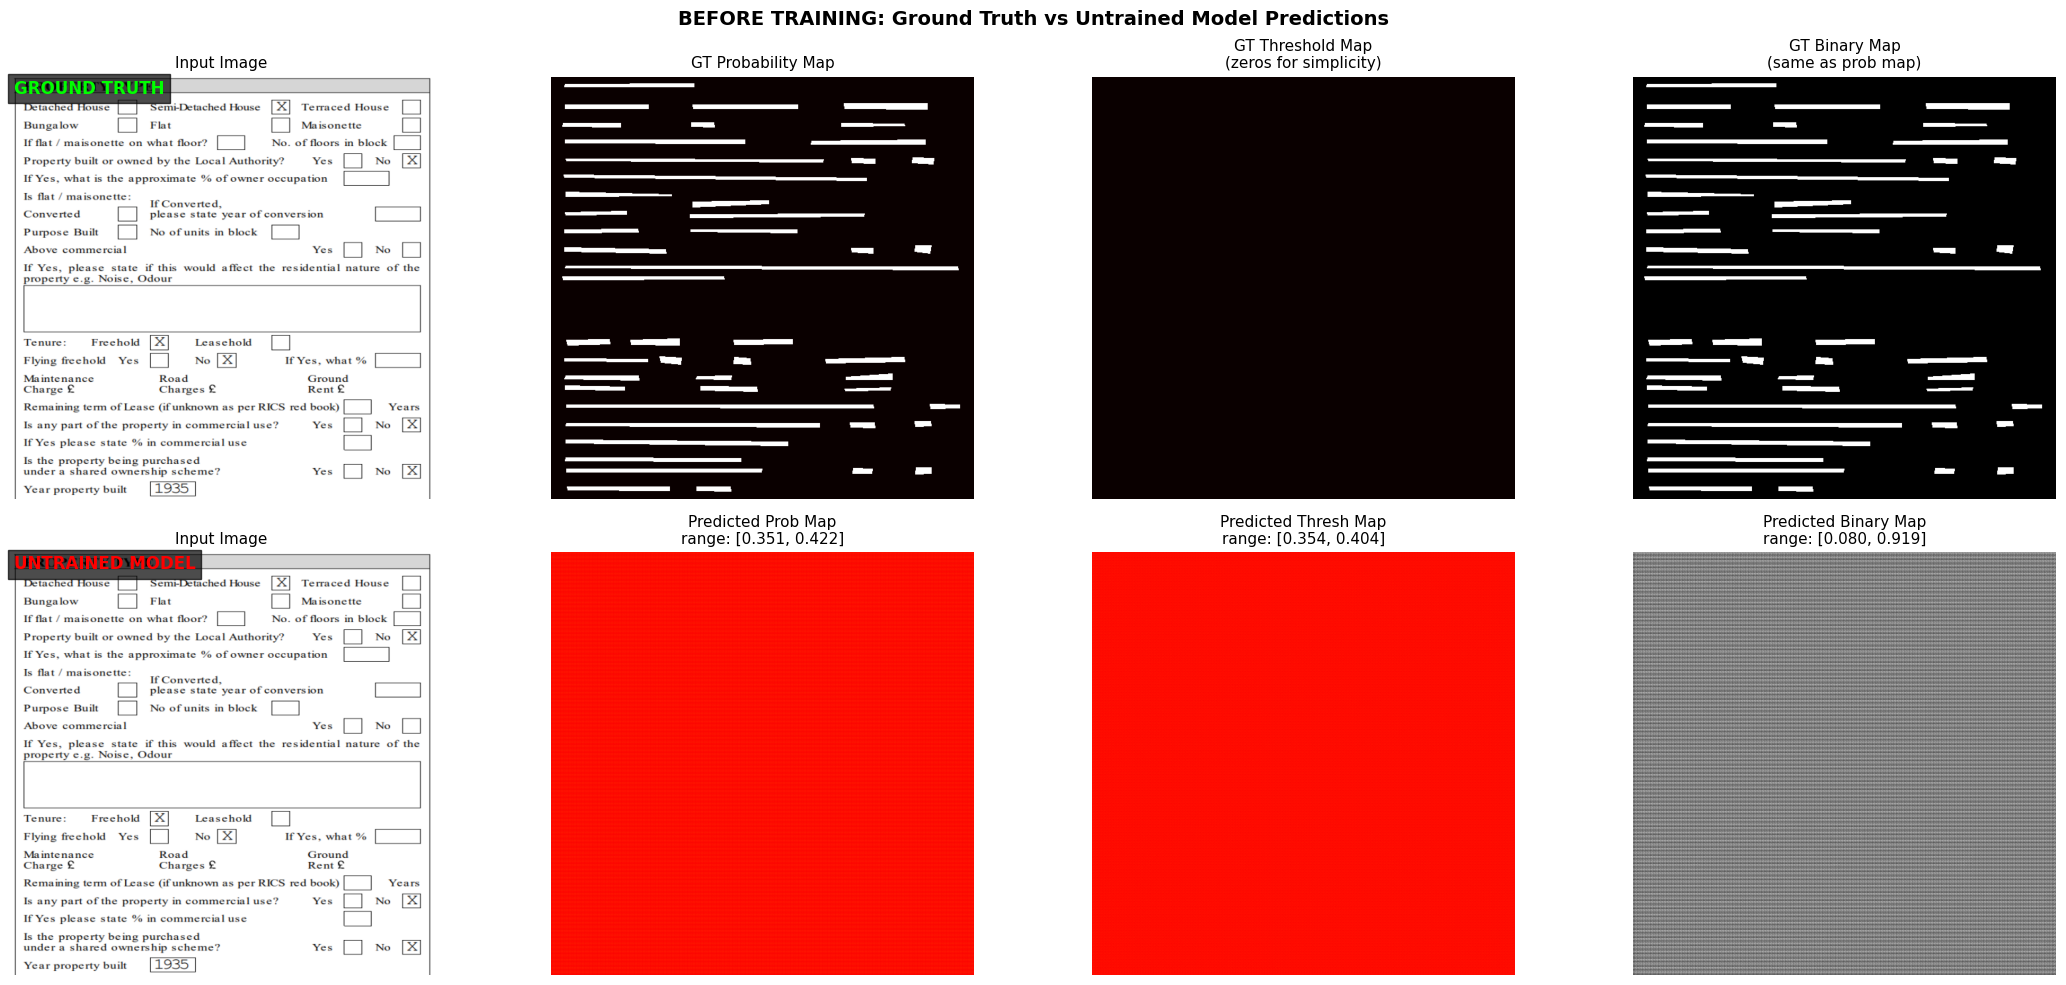

→ The untrained model outputs random noise. After training, it should match the GT!


In [10]:

with torch.no_grad():
    prob_pred, thresh_pred, binary_pred = model(img_tensor)

prob_np = prob_pred[0, 0].cpu().numpy()
thresh_np = thresh_pred[0, 0].cpu().numpy()
binary_np = binary_pred[0, 0].cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# Top row: Ground Truth
axes[0, 0].imshow(image_resized)
axes[0, 0].set_title('Input Image', fontsize=11)
axes[0, 1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
axes[0, 1].set_title('GT Probability Map', fontsize=11)
axes[0, 2].imshow(np.zeros_like(prob_map), cmap='hot', vmin=0, vmax=1)
axes[0, 2].set_title('GT Threshold Map\n(zeros for simplicity)', fontsize=11)
axes[0, 3].imshow(prob_map, cmap='gray', vmin=0, vmax=1)
axes[0, 3].set_title('GT Binary Map\n(same as prob map)', fontsize=11)

# Bottom row: Predictions (untrained)
axes[1, 0].imshow(image_resized)
axes[1, 0].set_title('Input Image', fontsize=11)
axes[1, 1].imshow(prob_np, cmap='hot', vmin=0, vmax=1)
axes[1, 1].set_title(f'Predicted Prob Map\nrange: [{prob_np.min():.3f}, {prob_np.max():.3f}]', fontsize=11)
axes[1, 2].imshow(thresh_np, cmap='hot', vmin=0, vmax=1)
axes[1, 2].set_title(f'Predicted Thresh Map\nrange: [{thresh_np.min():.3f}, {thresh_np.max():.3f}]', fontsize=11)
axes[1, 3].imshow(binary_np, cmap='gray', vmin=0, vmax=1)
axes[1, 3].set_title(f'Predicted Binary Map\nrange: [{binary_np.min():.3f}, {binary_np.max():.3f}]', fontsize=11)

for ax in axes.flatten():
    ax.axis('off')

axes[0, 0].text(5, 25, 'GROUND TRUTH', color='lime', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7))
axes[1, 0].text(5, 25, 'UNTRAINED MODEL', color='red', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7))

plt.suptitle('BEFORE TRAINING: Ground Truth vs Untrained Model Predictions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ The untrained model outputs random noise. After training, it should match the GT!")

In [11]:

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target, mask=None):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        if mask is not None:
            mask = mask.contiguous().view(-1)
            pred = pred * mask
            target = target * mask
        inter = (pred * target).sum()
        return 1 - (2 * inter + self.smooth) / (pred.sum() + target.sum() + self.smooth)


class OHEMBalancedBCELoss(nn.Module):
    def __init__(self, ratio=3):
        super().__init__()
        self.ratio = ratio

    def forward(self, pred, target, mask=None):
        eps = 1e-6
        pred = torch.clamp(pred, eps, 1 - eps)
        loss = -(target * torch.log(pred) + (1 - target) * torch.log(1 - pred))

        pos_mask = (target > 0.5).float()
        neg_mask = (target <= 0.5).float()
        if mask is not None:
            pos_mask *= mask
            neg_mask *= mask

        n_pos = pos_mask.sum().item()
        n_neg = min(int(n_pos * self.ratio), int(neg_mask.sum().item()))

        if n_pos == 0:
            return (loss * neg_mask).sum() / max(neg_mask.sum(), 1)

        pos_loss = (loss * pos_mask).sum()
        neg_vals = (loss * neg_mask).view(-1)

        if n_neg > 0:
            _, top_idx = torch.topk(neg_vals, k=n_neg)
            neg_loss = neg_vals[top_idx].sum()
        else:
            neg_loss = 0

        return (pos_loss + neg_loss) / (n_pos + n_neg + eps)


class DBNetLoss(nn.Module):
    def __init__(self, alpha=10.0, beta=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.dice = DiceLoss()
        self.ohem = OHEMBalancedBCELoss()
        self.l1 = nn.L1Loss(reduction='none')

    def forward(self, outputs, targets):
        prob_pred, thresh_pred, binary_pred = outputs
        prob_gt = targets['prob_map']
        thresh_gt = targets['thresh_map']
        thresh_mask = targets['thresh_mask']

        loss_prob = self.ohem(prob_pred, prob_gt) + self.dice(prob_pred, prob_gt)
        l1 = self.l1(thresh_pred, thresh_gt)
        loss_thresh = (l1 * thresh_mask).sum() / (thresh_mask.sum() + 1e-6)
        loss_binary = self.ohem(binary_pred, prob_gt) + self.dice(binary_pred, prob_gt)

        total = loss_prob + self.alpha * loss_thresh + self.beta * loss_binary
        return {'loss': total, 'loss_prob': loss_prob,
                'loss_thresh': loss_thresh, 'loss_binary': loss_binary}

criterion = DBNetLoss()
print("✓ Loss functions ready!")


✓ Loss functions ready!


In [12]:

# Prepare single-image batch
img_input = image_resized.astype(np.float32) / 255.0
img_input = torch.from_numpy(img_input).permute(2, 0, 1).unsqueeze(0).to(device)

prob_gt = torch.from_numpy(prob_map).unsqueeze(0).unsqueeze(0).to(device)
thresh_gt = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(device)
thresh_mask = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(device)

targets = {
    'prob_map': prob_gt,
    'thresh_map': thresh_gt,
    'thresh_mask': thresh_mask,
}

# Reset model with seed
torch.manual_seed(SEED)
model = DBNet(k=50).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = DBNetLoss(alpha=10.0, beta=1.0)

# Training
NUM_EPOCHS = 200
losses = []
snapshots = {}

print(f"{'='*60}")
print(f"OVERFITTING ON SINGLE IMAGE")
print(f"{'='*60}")
print(f"Training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad()

    outputs = model(img_input)
    loss_dict = criterion(outputs, targets)
    loss = loss_dict['loss']

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch + 1 in [1, 5, 10, 25, 50, 100, 150, 200]:
        model.eval()
        with torch.no_grad():
            p, t, b = model(img_input)
        snapshots[epoch + 1] = {
            'prob': p[0, 0].cpu().numpy(),
            'thresh': t[0, 0].cpu().numpy(),
            'binary': b[0, 0].cpu().numpy(),
        }
        print(f"  Epoch {epoch+1:3d}: Loss = {loss.item():.6f} | "
              f"Prob [{loss_dict['loss_prob'].item():.4f}] | "
              f"Binary [{loss_dict['loss_binary'].item():.4f}]")

print(f"\n✓ Training complete! Final loss: {losses[-1]:.6f}")

OVERFITTING ON SINGLE IMAGE
Training for 200 epochs...

  Epoch   1: Loss = 13.980228 | Prob [2.3304] | Binary [11.6498]
  Epoch   5: Loss = 3.823406 | Prob [1.5954] | Binary [2.2280]
  Epoch  10: Loss = 2.484508 | Prob [1.4857] | Binary [0.9988]
  Epoch  25: Loss = 1.833798 | Prob [1.3585] | Binary [0.4753]
  Epoch  50: Loss = 1.381130 | Prob [1.0392] | Binary [0.3420]
  Epoch 100: Loss = 0.564241 | Prob [0.4959] | Binary [0.0684]
  Epoch 150: Loss = 0.387170 | Prob [0.3292] | Binary [0.0579]
  Epoch 200: Loss = 0.325292 | Prob [0.2505] | Binary [0.0748]

✓ Training complete! Final loss: 0.325292


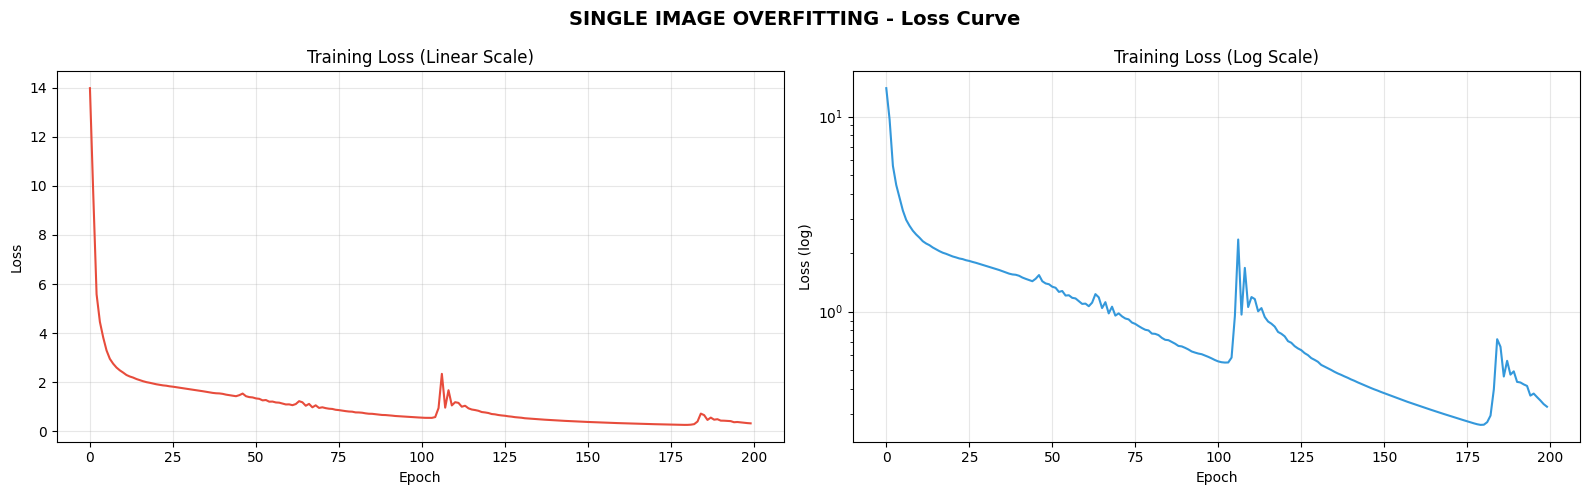

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(losses, color='#e74c3c', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Linear Scale)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(losses, color='#3498db', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log)')
axes[1].set_title('Training Loss (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle('SINGLE IMAGE OVERFITTING - Loss Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:

snap_epochs = sorted(snapshots.keys())

fig, axes = plt.subplots(3, len(snap_epochs), figsize=(3.5*len(snap_epochs), 10))

for col, ep in enumerate(snap_epochs):
    snap = snapshots[ep]

    axes[0, col].imshow(snap['prob'], cmap='hot', vmin=0, vmax=1)
    axes[0, col].set_title(f'Epoch {ep}', fontsize=10)

    axes[1, col].imshow(snap['thresh'], cmap='hot', vmin=0, vmax=1)

    axes[2, col].imshow(snap['binary'], cmap='gray', vmin=0, vmax=1)

axes[0, 0].set_ylabel('Probability Map', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Threshold Map', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('Binary Map', fontsize=12, fontweight='bold')

for ax in axes.flatten():
    ax.axis('off')

plt.suptitle('EVOLUTION: Watching DBNet Learn to Detect Text\n'
             'From random noise → accurate text regions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

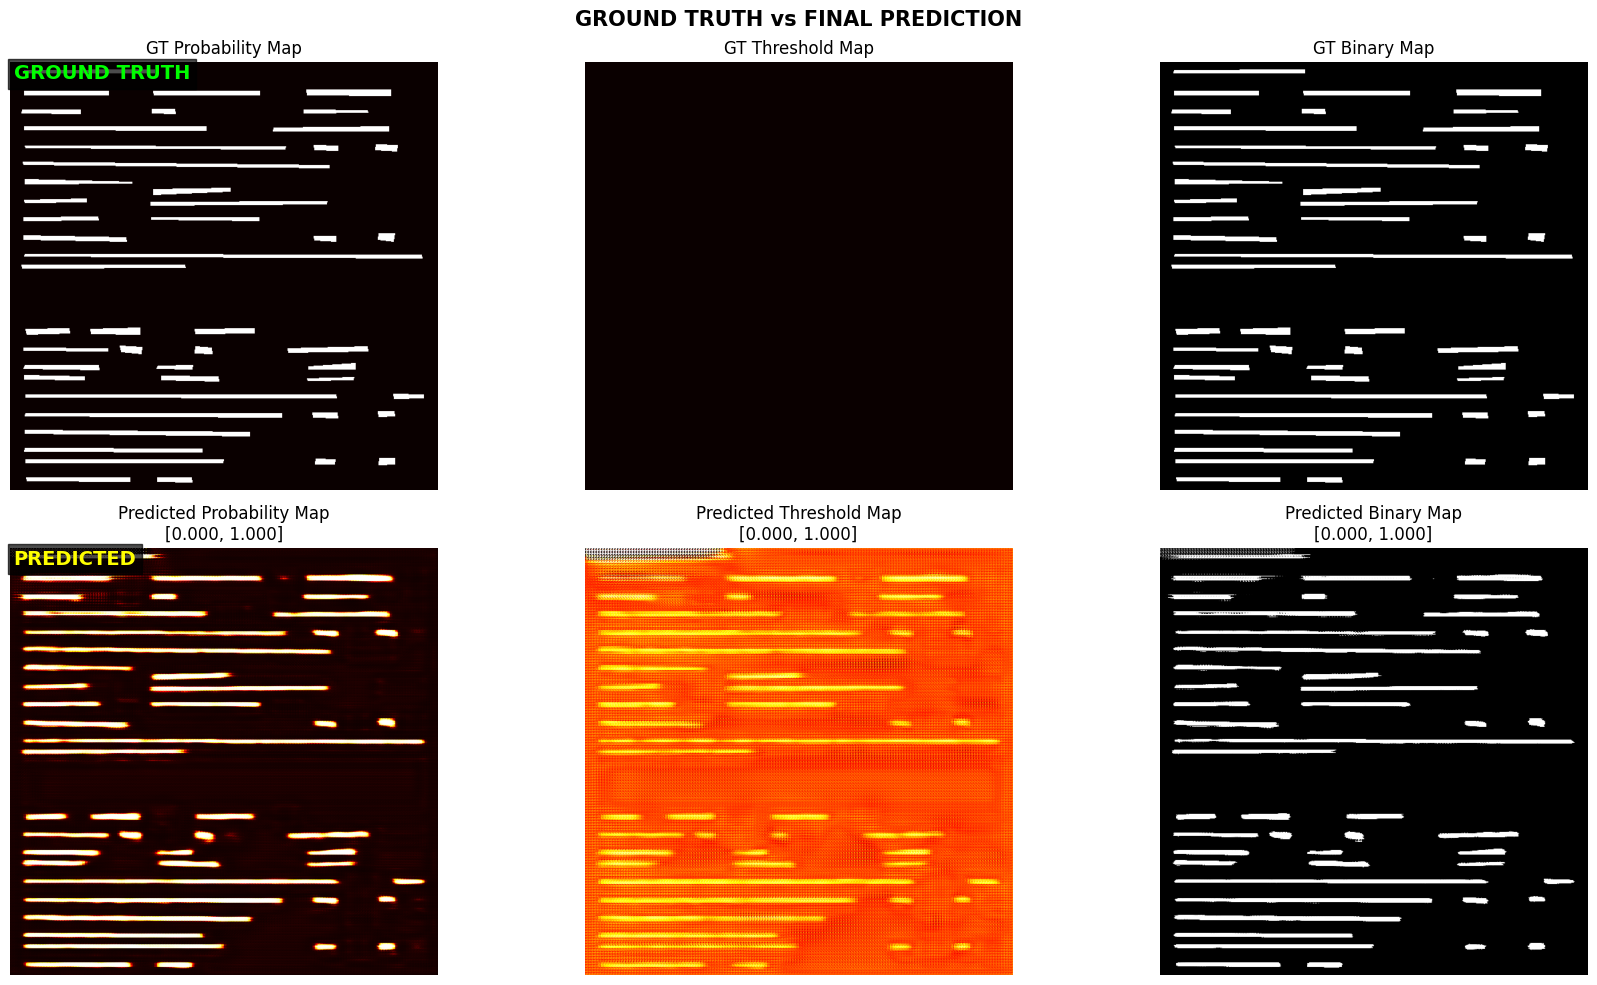

In [15]:

final = snapshots[max(snapshots.keys())]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
axes[0, 0].set_title('GT Probability Map')
axes[0, 1].imshow(np.zeros_like(prob_map), cmap='hot', vmin=0, vmax=1)
axes[0, 1].set_title('GT Threshold Map')
axes[0, 2].imshow(prob_map, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title('GT Binary Map')

axes[1, 0].imshow(final['prob'], cmap='hot', vmin=0, vmax=1)
axes[1, 0].set_title(f"Predicted Probability Map\n[{final['prob'].min():.3f}, {final['prob'].max():.3f}]")
axes[1, 1].imshow(final['thresh'], cmap='hot', vmin=0, vmax=1)
axes[1, 1].set_title(f"Predicted Threshold Map\n[{final['thresh'].min():.3f}, {final['thresh'].max():.3f}]")
axes[1, 2].imshow(final['binary'], cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title(f"Predicted Binary Map\n[{final['binary'].min():.3f}, {final['binary'].max():.3f}]")

for ax in axes.flatten():
    ax.axis('off')

axes[0, 0].text(5, 25, 'GROUND TRUTH', color='lime', fontsize=14, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7))
axes[1, 0].text(5, 25, 'PREDICTED', color='yellow', fontsize=14, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7))

plt.suptitle('GROUND TRUTH vs FINAL PREDICTION', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

BOX COMPARISON
  Ground Truth boxes:  49
  Predicted boxes:     49


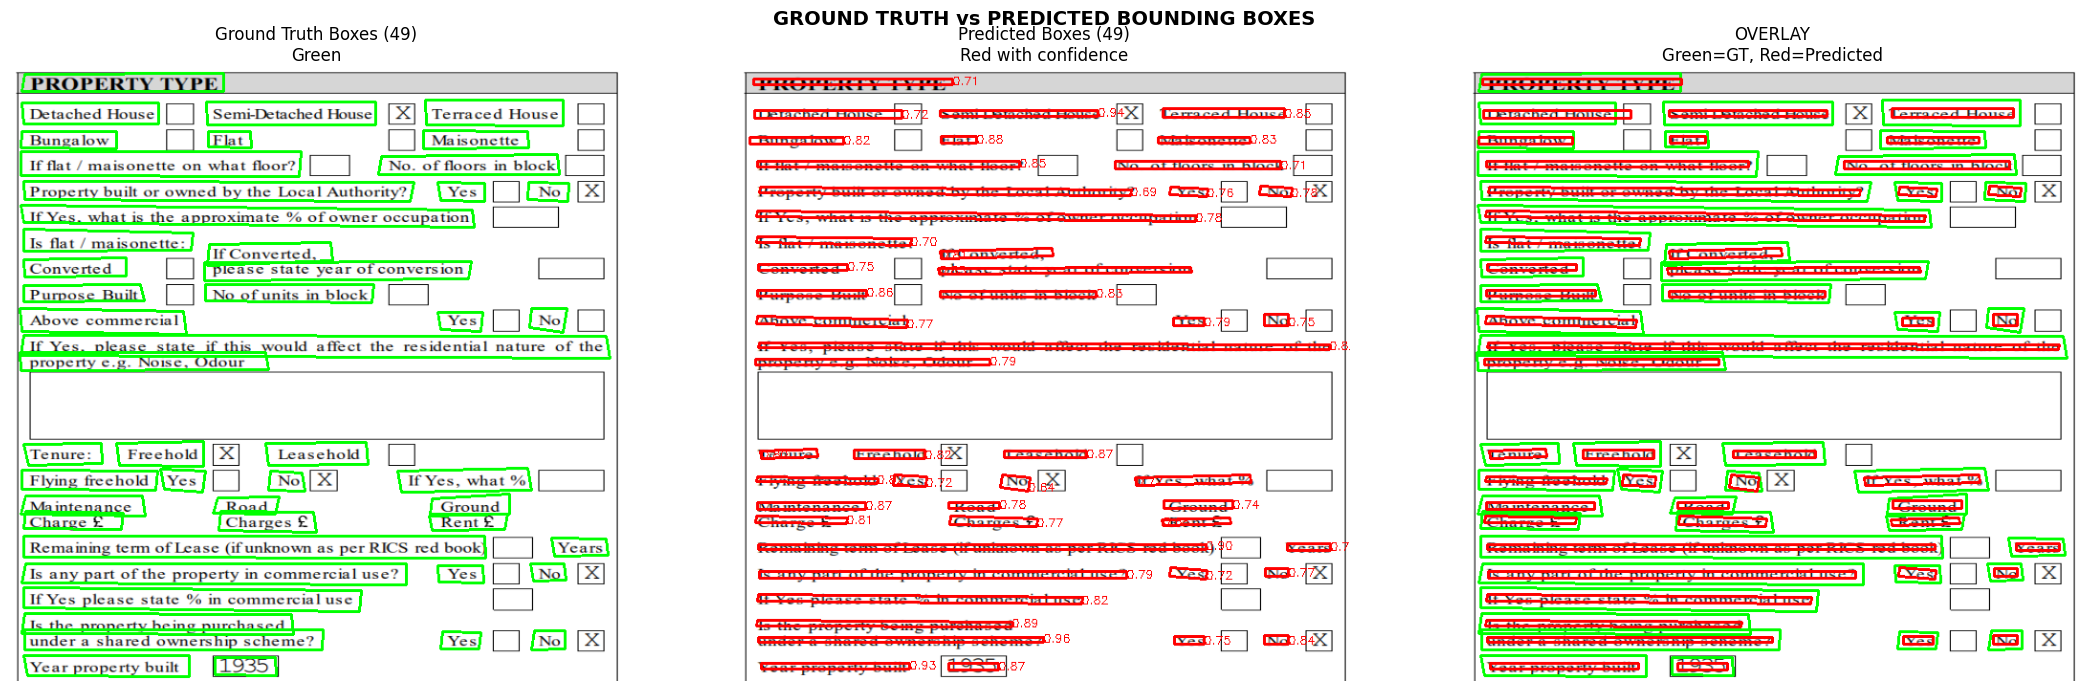

In [16]:

def extract_boxes(binary_map, prob_map, threshold=0.5, min_area=50):
    """Convert binary map to bounding boxes."""
    binary = (binary_map > threshold).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    scores = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect).astype(np.int32)

        mask = np.zeros(binary_map.shape, dtype=np.uint8)
        cv2.fillPoly(mask, [box], 1)
        score = (prob_map * mask).sum() / (mask.sum() + 1e-6)

        if score > 0.3:
            boxes.append(box)
            scores.append(float(score))

    return boxes, scores


# Get predicted boxes
pred_boxes, pred_scores = extract_boxes(final['binary'], final['prob'])

# GT boxes (scaled)
gt_boxes = [p.astype(np.int32) for p in scaled_polygons]

print(f"{'='*60}")
print(f"BOX COMPARISON")
print(f"{'='*60}")
print(f"  Ground Truth boxes:  {len(gt_boxes)}")
print(f"  Predicted boxes:     {len(pred_boxes)}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. GT boxes
img_gt = image_resized.copy()
for box in gt_boxes:
    cv2.polylines(img_gt, [box], True, (0, 255, 0), 2)
axes[0].imshow(img_gt)
axes[0].set_title(f'Ground Truth Boxes ({len(gt_boxes)})\nGreen', fontsize=12)
axes[0].axis('off')

# 2. Predicted boxes
img_pred = image_resized.copy()
for box, score in zip(pred_boxes, pred_scores):
    cv2.polylines(img_pred, [box], True, (255, 0, 0), 2)
    cv2.putText(img_pred, f'{score:.2f}', tuple(box[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
axes[1].imshow(img_pred)
axes[1].set_title(f'Predicted Boxes ({len(pred_boxes)})\nRed with confidence', fontsize=12)
axes[1].axis('off')

# 3. Overlay both
img_both = image_resized.copy()
for box in gt_boxes:
    cv2.polylines(img_both, [box], True, (0, 255, 0), 2)
for box in pred_boxes:
    cv2.polylines(img_both, [box], True, (255, 0, 0), 2)
axes[2].imshow(img_both)
axes[2].set_title(f'OVERLAY\nGreen=GT, Red=Predicted', fontsize=12)
axes[2].axis('off')

plt.suptitle('GROUND TRUTH vs PREDICTED BOUNDING BOXES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [17]:

def compute_iou(box1, box2):
    """Compute IoU between two polygons."""
    poly1 = Polygon(box1)
    poly2 = Polygon(box2)

    if not poly1.is_valid or not poly2.is_valid:
        return 0.0

    inter = poly1.intersection(poly2).area
    union = poly1.union(poly2).area

    return inter / union if union > 0 else 0.0


print(f"\n{'='*60}")
print(f"IoU ANALYSIS (Intersection over Union)")
print(f"{'='*60}")
print(f"\n  IoU measures overlap between GT and predicted boxes")
print(f"  IoU = 1.0 → perfect match, IoU = 0.0 → no overlap\n")

matched = 0
for i, gt_box in enumerate(gt_boxes):
    best_iou = 0
    best_pred_idx = -1

    for j, pred_box in enumerate(pred_boxes):
        iou = compute_iou(gt_box, pred_box)
        if iou > best_iou:
            best_iou = iou
            best_pred_idx = j

    status = "✓" if best_iou > 0.5 else "✗"
    if best_iou > 0.5:
        matched += 1

    text_label = texts[i][:20] if i < len(texts) else ''
    print(f"  {status} GT[{i:2d}] '{text_label}' → Best IoU: {best_iou:.4f}" +
          (f" (matched pred[{best_pred_idx}])" if best_pred_idx >= 0 else ""))

print(f"\n  Summary: {matched}/{len(gt_boxes)} GT boxes matched (IoU > 0.5)")


IoU ANALYSIS (Intersection over Union)

  IoU measures overlap between GT and predicted boxes
  IoU = 1.0 → perfect match, IoU = 0.0 → no overlap

  ✗ GT[ 0] 'how are you' → Best IoU: 0.2208 (matched pred[41])
  ✗ GT[ 1] 'd' → Best IoU: 0.3395 (matched pred[46])
  ✗ GT[ 2] 'd' → Best IoU: 0.2337 (matched pred[45])
  ✗ GT[ 3] 'd' → Best IoU: 0.3006 (matched pred[47])
  ✗ GT[ 4] 'd' → Best IoU: 0.2922 (matched pred[42])
  ✗ GT[ 5] 'd' → Best IoU: 0.3939 (matched pred[43])
  ✗ GT[ 6] 'd' → Best IoU: 0.3529 (matched pred[44])
  ✗ GT[ 7] 'e' → Best IoU: 0.3711 (matched pred[40])
  ✗ GT[ 8] 'd' → Best IoU: 0.2947 (matched pred[37])
  ✗ GT[ 9] 'd' → Best IoU: 0.3485 (matched pred[38])
  ✗ GT[10] 'd' → Best IoU: 0.3841 (matched pred[39])
  ✗ GT[11] 'f' → Best IoU: 0.3256 (matched pred[36])
  ✗ GT[12] 'f' → Best IoU: 0.2906 (matched pred[35])
  ✗ GT[13] 'f' → Best IoU: 0.2831 (matched pred[33])
  ✗ GT[14] 'f' → Best IoU: 0.2833 (matched pred[32])
  ✗ GT[15] 'f' → Best IoU: 0.3551 (matched pred


DIFFERENTIABLE BINARIZATION - The Core of DBNet

  Standard binarization:  B = 1 if P > t else 0  (NOT differentiable!)
  DBNet binarization:     B = sigmoid(k × (P - T))  (differentiable!)

  Where:
    P = Probability map (predicted text probability per pixel)
    T = Threshold map (adaptive threshold per pixel)
    k = 50 (amplification factor - makes sigmoid steep)
    B = Binary map (final text/background decision)



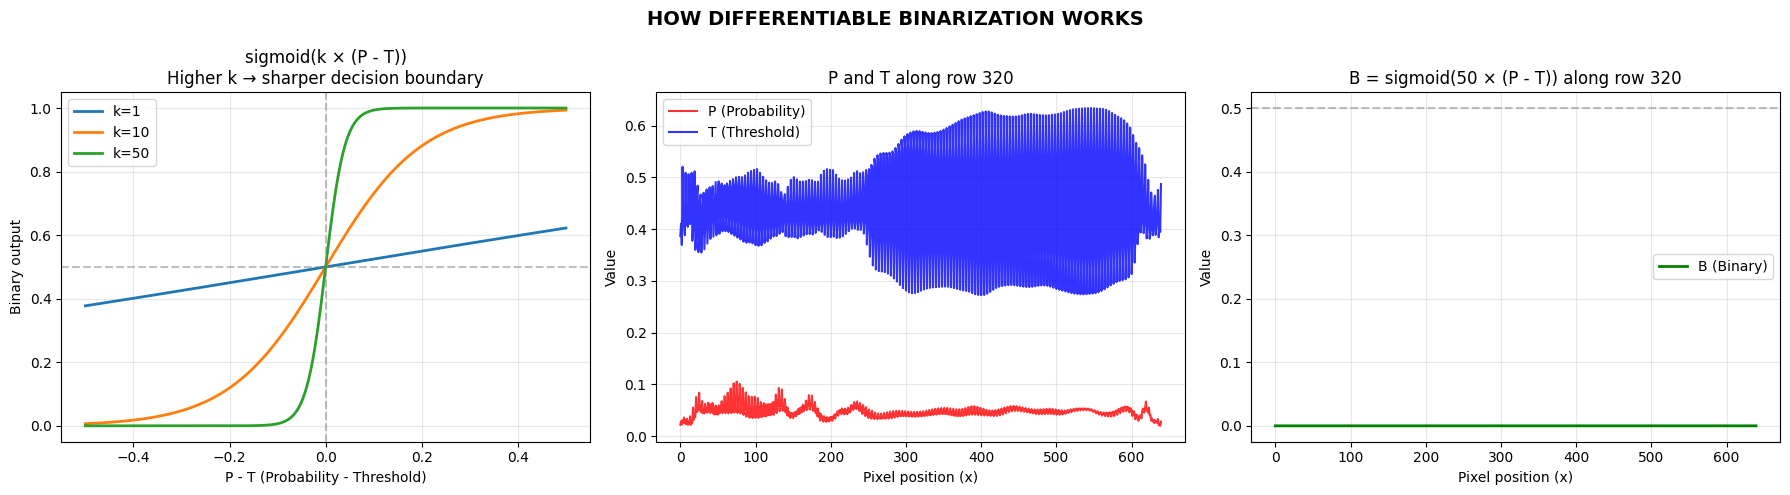

In [18]:

print(f"\n{'='*60}")
print(f"DIFFERENTIABLE BINARIZATION - The Core of DBNet")
print(f"{'='*60}")
print(f"""
  Standard binarization:  B = 1 if P > t else 0  (NOT differentiable!)
  DBNet binarization:     B = sigmoid(k × (P - T))  (differentiable!)

  Where:
    P = Probability map (predicted text probability per pixel)
    T = Threshold map (adaptive threshold per pixel)
    k = 50 (amplification factor - makes sigmoid steep)
    B = Binary map (final text/background decision)
""")

x_vals = np.linspace(-0.5, 0.5, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for k_val in [1, 10, 50]:
    y_vals = 1 / (1 + np.exp(-k_val * x_vals))
    axes[0].plot(x_vals, y_vals, linewidth=2, label=f'k={k_val}')

axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('P - T (Probability - Threshold)')
axes[0].set_ylabel('Binary output')
axes[0].set_title('sigmoid(k × (P - T))\nHigher k → sharper decision boundary')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

row = IMG_SIZE // 2
axes[1].plot(final['prob'][row], label='P (Probability)', color='red', alpha=0.8)
axes[1].plot(final['thresh'][row], label='T (Threshold)', color='blue', alpha=0.8)
axes[1].set_title(f'P and T along row {row}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Pixel position (x)')
axes[1].set_ylabel('Value')

axes[2].plot(final['binary'][row], label='B (Binary)', color='green', linewidth=2)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title(f'B = sigmoid(50 × (P - T)) along row {row}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Pixel position (x)')
axes[2].set_ylabel('Value')

plt.suptitle('HOW DIFFERENTIABLE BINARIZATION WORKS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [19]:

print(f"""
{'='*60}
COMPLETE PIPELINE SUMMARY
{'='*60}

┌─────────────────────────────────────────────────────────┐
│  INPUT IMAGE ({W}×{H}×3)                               │
│  ↓ Resize to {IMG_SIZE}×{IMG_SIZE}                               │
│  ↓ Normalize to [0, 1]                                 │
│  ↓ Shape: (1, 3, {IMG_SIZE}, {IMG_SIZE})                          │
├─────────────────────────────────────────────────────────┤
│  BACKBONE (ResNet-18)                                   │
│  ↓ C1: (1, 64,  {IMG_SIZE//4}, {IMG_SIZE//4})   — 1/4 resolution            │
│  ↓ C2: (1, 128, {IMG_SIZE//8}, {IMG_SIZE//8})   — 1/8 resolution             │
│  ↓ C3: (1, 256, {IMG_SIZE//16}, {IMG_SIZE//16})   — 1/16 resolution            │
│  ↓ C4: (1, 512, {IMG_SIZE//32}, {IMG_SIZE//32})   — 1/32 resolution            │
├─────────────────────────────────────────────────────────┤
│  FPN (Feature Pyramid Network)                          │
│  ↓ Fuse all scales → (1, 256, {IMG_SIZE//4}, {IMG_SIZE//4})              │
├─────────────────────────────────────────────────────────┤
│  DETECTION HEAD                                         │
│  ↓ Probability Map P: (1, 1, {IMG_SIZE}, {IMG_SIZE})              │
│  ↓ Threshold Map  T: (1, 1, {IMG_SIZE}, {IMG_SIZE})              │
│  ↓ Binary Map     B: (1, 1, {IMG_SIZE}, {IMG_SIZE})              │
│  ↓ B = sigmoid(50 × (P - T))                           │
├─────────────────────────────────────────────────────────┤
│  POST-PROCESSING                                        │
│  ↓ Threshold binary map > 0.5                           │
│  ↓ Find contours                                        │
│  ↓ Fit minimum area rectangles                          │
│  ↓ Filter by area and score                             │
│  → Final bounding boxes!                                │
└─────────────────────────────────────────────────────────┘

Training Results:
  GT boxes:        {len(gt_boxes)}
  Predicted boxes: {len(pred_boxes)}
  Final loss:      {losses[-1]:.6f}
  Matched (IoU>.5): {matched}/{len(gt_boxes)}
""")



COMPLETE PIPELINE SUMMARY

┌─────────────────────────────────────────────────────────┐
│  INPUT IMAGE (592×748×3)                               │
│  ↓ Resize to 640×640                               │
│  ↓ Normalize to [0, 1]                                 │
│  ↓ Shape: (1, 3, 640, 640)                          │
├─────────────────────────────────────────────────────────┤
│  BACKBONE (ResNet-18)                                   │
│  ↓ C1: (1, 64,  160, 160)   — 1/4 resolution            │
│  ↓ C2: (1, 128, 80, 80)   — 1/8 resolution             │
│  ↓ C3: (1, 256, 40, 40)   — 1/16 resolution            │
│  ↓ C4: (1, 512, 20, 20)   — 1/32 resolution            │
├─────────────────────────────────────────────────────────┤
│  FPN (Feature Pyramid Network)                          │
│  ↓ Fuse all scales → (1, 256, 160, 160)              │
├─────────────────────────────────────────────────────────┤
│  DETECTION HEAD                                         │
│  ↓ Probability Map P: (1, 1

PIXEL-LEVEL IoU MEASUREMENT

  GT binary map shape:   (640, 640)
  Pred binary map shape: (640, 640)
  ✓ Both maps are 640×640

  ┌────────────────────────────────────────────┐
  │           CONFUSION MATRIX (Pixels)        │
  ├──────────────┬─────────────┬───────────────┤
  │              │ Pred = Text │ Pred = BG     │
  ├──────────────┼─────────────┼───────────────┤
  │ GT = Text    │ TP = 42,580 │ FN =  2,373  │
  │ GT = BG      │ FP =  2,744 │ TN = 361,903  │
  └──────────────┴─────────────┴───────────────┘

  Intersection (TP):  42,580 pixels
  Union (TP+FP+FN):  47,697 pixels

  ─── METRICS ───
  Pixel IoU:    0.8927  (89.27%)
  Precision:    0.9395  (93.95%)
  Recall:       0.9472  (94.72%)
  F1 Score:     0.9433  (94.33%)
  Accuracy:     0.9875  (98.75%)


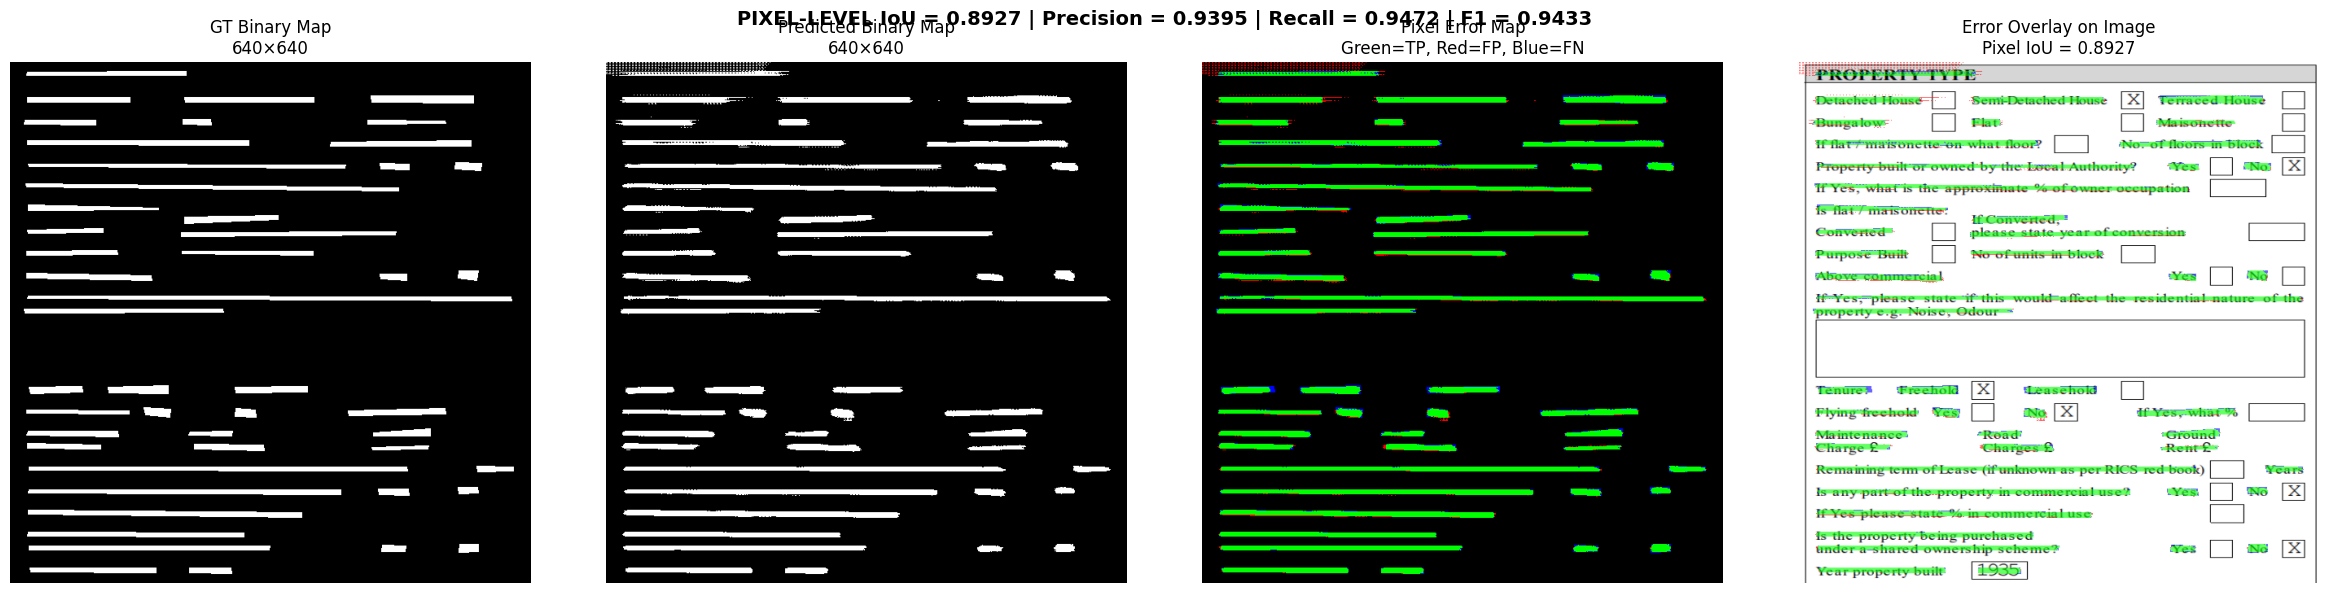


✓ Deep dive complete!


In [25]:

print(f"{'='*60}")
print(f"PIXEL-LEVEL IoU MEASUREMENT")
print(f"{'='*60}")

# Both maps are already the same size: (IMG_SIZE, IMG_SIZE) = (640, 640)
# GT:   prob_map        → shape (640, 640), values 0.0 or 1.0
# Pred: final['binary'] → shape (640, 640), values in [0, 1]

gt_binary = (prob_map > 0.5).astype(np.uint8)          # (640, 640)
pred_binary = (final['binary'] > 0.5).astype(np.uint8) # (640, 640)

assert gt_binary.shape == pred_binary.shape, \
    f"Shape mismatch! GT: {gt_binary.shape}, Pred: {pred_binary.shape}"

print(f"\n  GT binary map shape:   {gt_binary.shape}")
print(f"  Pred binary map shape: {pred_binary.shape}")
print(f"  ✓ Both maps are {IMG_SIZE}×{IMG_SIZE}\n")

# --- Pixel counts ---
TP = int(((gt_binary == 1) & (pred_binary == 1)).sum())  # True Positive
FP = int(((gt_binary == 0) & (pred_binary == 1)).sum())  # False Positive
FN = int(((gt_binary == 1) & (pred_binary == 0)).sum())  # False Negative
TN = int(((gt_binary == 0) & (pred_binary == 0)).sum())  # True Negative

total = TP + FP + FN + TN
intersection = TP
union = TP + FP + FN

# --- Metrics ---
pixel_iou = intersection / (union + 1e-6)
precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)
accuracy = (TP + TN) / total

print(f"  ┌────────────────────────────────────────────┐")
print(f"  │           CONFUSION MATRIX (Pixels)        │")
print(f"  ├──────────────┬─────────────┬───────────────┤")
print(f"  │              │ Pred = Text │ Pred = BG     │")
print(f"  ├──────────────┼─────────────┼───────────────┤")
print(f"  │ GT = Text    │ TP = {TP:6,} │ FN = {FN:6,}  │")
print(f"  │ GT = BG      │ FP = {FP:6,} │ TN = {TN:6,}  │")
print(f"  └──────────────┴─────────────┴───────────────┘")
print(f"\n  Intersection (TP):  {intersection:,} pixels")
print(f"  Union (TP+FP+FN):  {union:,} pixels")
print(f"\n  ─── METRICS ───")
print(f"  Pixel IoU:    {pixel_iou:.4f}  ({pixel_iou*100:.2f}%)")
print(f"  Precision:    {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall:       {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score:     {f1:.4f}  ({f1*100:.2f}%)")
print(f"  Accuracy:     {accuracy:.4f}  ({accuracy*100:.2f}%)")

# --- Color-coded visualization ---
# Green = TP (correct text), Red = FP (false alarm), Blue = FN (missed text)
error_map = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
error_map[(gt_binary == 1) & (pred_binary == 1)] = [0, 255, 0]    # TP → Green
error_map[(gt_binary == 0) & (pred_binary == 1)] = [255, 0, 0]    # FP → Red
error_map[(gt_binary == 1) & (pred_binary == 0)] = [0, 0, 255]    # FN → Blue
# TN stays black (background correctly predicted as background)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(gt_binary, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'GT Binary Map\n{IMG_SIZE}×{IMG_SIZE}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(pred_binary, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Predicted Binary Map\n{IMG_SIZE}×{IMG_SIZE}', fontsize=12)
axes[1].axis('off')

axes[2].imshow(error_map)
axes[2].set_title(f'Pixel Error Map\nGreen=TP, Red=FP, Blue=FN', fontsize=12)
axes[2].axis('off')

# Overlay error map on image
overlay = image_resized.copy().astype(np.float32)
error_mask = (error_map.sum(axis=2) > 0)
overlay[error_mask] = overlay[error_mask] * 0.4 + error_map[error_mask].astype(np.float32) * 0.6
axes[3].imshow(overlay.astype(np.uint8))
axes[3].set_title(f'Error Overlay on Image\nPixel IoU = {pixel_iou:.4f}', fontsize=12)
axes[3].axis('off')

plt.suptitle(f'PIXEL-LEVEL IoU = {pixel_iou:.4f} | Precision = {precision:.4f} | '
             f'Recall = {recall:.4f} | F1 = {f1:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Deep dive complete!")